# Wikipedia Best-Selling Books Data Project  
### Data Scraping, Cleaning, Analysis, and Visualization by Oluwatimilehin Olugbade

### Importing Necessary libraries for data scraping

In [1]:
import pandas as pd
import requests
from io import StringIO

In [2]:
#The Website the best selling books dataset is located
url = 'https://en.wikipedia.org/wiki/List_of_best-selling_books'

### Scraping the tables from the website

In [3]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()


In [4]:
html = StringIO(response.text)
tables = pd.read_html(html)

### Converting our tables to a  dataframe

In [5]:

for i, table in enumerate(tables):
    print(f"\nTable {i}")
    print(table.head())


Table 0
                                       Book                 Author(s)  \
0                      A Tale of Two Cities           Charles Dickens   
1       The Little Prince (Le Petit Prince)  Antoine de Saint-Exupéry   
2              The Alchemist (O Alquimista)              Paulo Coelho   
3  Harry Potter and the Philosopher's Stone             J. K. Rowling   
4                  And Then There Were None           Agatha Christie   

  Original language  First published        Approximate sales  \
0           English             1859         >200 million[20]   
1            French             1943  200 million[21][22][23]   
2        Portuguese             1988      150 million[24][25]   
3           English             1997      120 million[26][27]   
4           English             1939          100 million[28]   

                Genre  
0  Historical fiction  
1             Fantasy  
2             Fantasy  
3             Fantasy  
4             Mystery  

Table 1
        

I loaded 14 tables from the link. Most of them share similar columns, although a few contain unique columns that will be removed later because they are either irrelevant or appear in only a small number of tables.

I will concatenate all the tables into a single DataFrame called `Data`.

Next, I will merge columns that represent the same information but use different names, and then remove the less relevant columns.

In [6]:
Data = pd.concat(tables[0:14], ignore_index=True)

In [7]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Book                  205 non-null    str    
 1   Author(s)             334 non-null    str    
 2   Original language     336 non-null    str    
 3   First published       302 non-null    object 
 4   Approximate sales     266 non-null    str    
 5   Genre                 135 non-null    str    
 6   Approx. sales         70 non-null     str    
 7   Book series           131 non-null    str    
 8   No. of installments   110 non-null    str    
 9   Years of Publication  34 non-null     str    
 10  No. of instalments    16 non-null     float64
dtypes: float64(1), object(1), str(9)
memory usage: 29.0+ KB


In [10]:
Data["Approximate Sales"] = Data["Approximate sales"].fillna(Data["Approx. sales"])
Data["First Published"] = Data["Years of Publication"].fillna(Data["First published"])
Data['Book Title'] = Data['Book'].fillna(Data['Book series'])

In [11]:
#loading our new column Data[['Sales','Published']]
Data[['Approximate Sales','First Published', 'Book Title']]

,Approximate Sales,First Published,Book Title
0,>200 million[20],1859,A Tale of Two Cities
1,200 million[21][22][23],1943,The Little Prince (Le Petit Prince)
2,150 million[24][25],1988,The Alchemist (O Alquimista)
3,120 million[26][27],1997,Harry Potter and the Philosopher's Stone
4,100 million[28],1939,And Then There Were None
...,...,...,...
331,11 million[368],1960,"旺文社古語辞典 (Obunsha Kogo Jiten) ""Obunsha Dictiona..."
332,11 million[369],(Up to 1965),Hammond's Pocket Atlas
333,10 million[370],1960,"三省堂国語辞典 (Sanseido Kokugo Jiten) ""Sanseido Dict..."
334,10 million[371],1925,家庭に於ける実際的看護の秘訣 (Katei Ni Okeru Jissaiteki Kang...


In [12]:
Data[['Approximate Sales','First Published', 'Book Title']].isna().sum()

Approximate Sales    0
First Published      0
Book Title           0
dtype: int64

### Dropping redundant columns

In [14]:
Data.columns

Index(['Book', 'Author(s)', 'Original language', 'First published',
       'Approximate sales', 'Genre', 'Approx. sales', 'Book series',
       'No. of installments', 'Years of Publication', 'No. of instalments',
       'Approximate Sales', 'First Published', 'Book Title'],
      dtype='str')

**Using the output above I will create a list of columns to keep and columns to drop**

In [15]:
columns_to_keep =['Book Title', 'Author(s)', 'Original language', 'Genre', 'Approximate Sales', 'First Published']
columns_to_drop = ['Book', 'First published', 'Approximate sales', 'Approx. sales', 'Book series', 'No. of installments', 'Years of Publication', 'No. of instalments']

**Filtering the dataset**

In [16]:
Data[columns_to_keep]

,Book Title,Author(s),Original language,Genre,Approximate Sales,First Published
0,A Tale of Two Cities,Charles Dickens,English,Historical fiction,>200 million[20],1859
1,The Little Prince (Le Petit Prince),Antoine de Saint-Exupéry,French,Fantasy,200 million[21][22][23],1943
2,The Alchemist (O Alquimista),Paulo Coelho,Portuguese,Fantasy,150 million[24][25],1988
3,Harry Potter and the Philosopher's Stone,J. K. Rowling,English,Fantasy,120 million[26][27],1997
4,And Then There Were None,Agatha Christie,English,Mystery,100 million[28],1939
...,...,...,...,...,...,...
331,"旺文社古語辞典 (Obunsha Kogo Jiten) ""Obunsha Dictiona...",Akira Matsumura,Japanese,NaN,11 million[368],1960
332,Hammond's Pocket Atlas,NaN,English,NaN,11 million[369],(Up to 1965)
333,"三省堂国語辞典 (Sanseido Kokugo Jiten) ""Sanseido Dict...",Kenbō Hidetoshi,Japanese,NaN,10 million[370],1960
334,家庭に於ける実際的看護の秘訣 (Katei Ni Okeru Jissaiteki Kang...,Takichi Tsukuda,Japanese,NaN,10 million[371],1925


In [17]:
Data.drop(columns= columns_to_drop, inplace = True)

In [18]:
Data

,Author(s),Original language,Genre,Approximate Sales,First Published,Book Title
0,Charles Dickens,English,Historical fiction,>200 million[20],1859,A Tale of Two Cities
1,Antoine de Saint-Exupéry,French,Fantasy,200 million[21][22][23],1943,The Little Prince (Le Petit Prince)
2,Paulo Coelho,Portuguese,Fantasy,150 million[24][25],1988,The Alchemist (O Alquimista)
3,J. K. Rowling,English,Fantasy,120 million[26][27],1997,Harry Potter and the Philosopher's Stone
4,Agatha Christie,English,Mystery,100 million[28],1939,And Then There Were None
...,...,...,...,...,...,...
331,Akira Matsumura,Japanese,NaN,11 million[368],1960,"旺文社古語辞典 (Obunsha Kogo Jiten) ""Obunsha Dictiona..."
332,NaN,English,NaN,11 million[369],(Up to 1965),Hammond's Pocket Atlas
333,Kenbō Hidetoshi,Japanese,NaN,10 million[370],1960,"三省堂国語辞典 (Sanseido Kokugo Jiten) ""Sanseido Dict..."
334,Takichi Tsukuda,Japanese,NaN,10 million[371],1925,家庭に於ける実際的看護の秘訣 (Katei Ni Okeru Jissaiteki Kang...


### Creating a standard column Title format for the dataset.

In [19]:
new_column_format = []
for x in Data.columns:
    new_column_format.append(x.title()) #Converts column names to Title Case 

In [20]:
new_column_format

['Author(S)',
 'Original Language',
 'Genre',
 'Approximate Sales',
 'First Published',
 'Book Title']

In [22]:
Data.columns = new_column_format #Permanentely Modifies the columns using the new title fomrat

### Checking for duplicate data


In [23]:
Data.duplicated().sum() #shows the sum of the duplicate data

np.int64(0)

### Handling null values

In [24]:
Data.isna().sum()

Author(S)              2
Original Language      0
Genre                201
Approximate Sales      0
First Published        0
Book Title             0
dtype: int64

In [80]:
#dropping the 'Genre' column because it has a large number of null values and it wont be relevant to our analysis
Data.drop(columns = ['Genre'], inplace = True)

In [27]:
Data['Genre'].isna().sum()

np.int64(0)

In [30]:
#since the null values in Authors column are just two, I am going to manually fill them 
Data[Data["Author(S)"].isna()]

,Author(S),Original Language,Genre,Approximate Sales,First Published,Book Title
327,NaN,English,Unknown,15.11 million[364],(Up to 1975),Merriam-Webster Pocket Dictionary
332,NaN,English,Unknown,11 million[369],(Up to 1965),Hammond's Pocket Atlas


In [ ]:
#Manually filling the missing authors
Data.loc[327, "Author(S)"] = "Merriam-Webster"
Data.loc[332, "Author(S)"] = "Hammond"

In [32]:
Data['Author(S)'].isna().sum()

np.int64(0)

### Cleaning Individual Columns

The `Approximate Sales` column contains text, references, and notes such as citation brackets and phrases like `(as of 2005)`. I cleaned the column by removing those extra parts, extracting the numeric value, and converting values in millions into standard numeric format for analysis.

In [38]:
#Creating a function to clean the "Approximate Sales" column
import re
def clean_sales(value):
    if pd.isna(value):
        return None
    
    value = str(value).lower().strip()
    
    # remove references like [192]
    value = re.sub(r"\[.*?\]", "", value)
    
    # remove text in parentheses like (as of 2005)
    value = re.sub(r"\(.*?\)", "", value)
    
    # remove commas and extra spaces
    value = value.replace(",", "").strip()
    
    # extract number
    match = re.search(r"(\d+(\.\d+)?)", value)
    if not match:
        return None
    
    number = float(match.group(1))
    
    # convert million / billion
    if "million" in value:
        return number * 1_000_000
    else:
        return number

In [41]:
Data["Approximate Sales Clean"] = Data["Approximate Sales"].apply(clean_sales)

In [42]:
#checking to see if I got the desired result with the function before making it permanent
Data["Approximate Sales Clean"]

0      200000000.0
1      200000000.0
2      150000000.0
3      120000000.0
4      100000000.0
          ...     
331     11000000.0
332     11000000.0
333     10000000.0
334     10000000.0
335     10000000.0
Name: Approximate Sales Clean, Length: 336, dtype: float64

In [ ]:
#dropping test column
Data.drop(columns = ['Approximate Sales Clean'], inplace = True)

In [43]:
Data["Approximate Sales"] = Data["Approximate Sales"].apply(clean_sales)

In [44]:
#converting to an integer value
Data["Approximate Sales"] = Data["Approximate Sales"].astype("Int64")

In [45]:
Data["Approximate Sales"]

0      200000000
1      200000000
2      150000000
3      120000000
4      100000000
         ...    
331     11000000
332     11000000
333     10000000
334     10000000
335     10000000
Name: Approximate Sales, Length: 336, dtype: Int64

The `First Published` column contains mixed formats, so I extracted only the first year from each entry to create a cleaner numeric year column for analysis.

In [34]:
Data["First Published"] = Data["First Published"].astype(str).str.extract(r"(\d{4})")
Data["First Published"] = pd.to_numeric(Data["First Published"], errors="coerce")

In [46]:
Data["First Published"]

0      1859
1      1943
2      1988
3      1997
4      1939
       ... 
331    1960
332    1965
333    1960
334    1925
335    1991
Name: First Published, Length: 336, dtype: int64

**removes trailing and leading spaces from all text values in all columns**

In [49]:
Data = Data.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [81]:
Data.to_csv('Wikipedia_book_best_seller data.csv', index=False)

### Analyzing our cleaned dataset

In [ ]:
#Top 10 books by total copy sold(Approxiamte Sales)
top_books = Data.sort_values("Approximate Sales", ascending=False)[
    ["Book Title", "Author(S)", "Approximate Sales", "First Published", "Original Language"]
].head(10)

print("\nTop 10 Best Selling Books by Sales:")
top_books


Top 10 Best Selling Books by Sales:


,Book Title,Author(S),Approximate Sales,First Published,Original Language
172,Harry Potter,J. K. Rowling,600000000,1997,English
303,新华字典 (Xinhua Zidian / Xinhua Dictionary),Chief editor: Wei Jiangong,567000000,1957,Chinese
173,Goosebumps,R. L. Stine,400000000,1992,English
175,Diary of a Wimpy Kid,Jeff Kinney,300000000,2004,English
174,Perry Mason,Erle Stanley Gardner,300000000,1933,English
176,Berenstain Bears,Stan and Jan Berenstain,260000000,1962,English
179,Noddy,"Enid Blyton, various other authors",250000000,1949,English
177,Choose Your Own Adventure,Various authors,250000000,1979,English
178,Sweet Valley High,Francine Pascal and ghostwriters,250000000,1983,English
181,The Railway Series and Thomas & Friends,"Wilbert Awdry, Christopher Awdry, various othe...",200000000,1945,English


In [57]:
sales_by_language = (
    Data.groupby("Original Language")["Approximate Sales"].sum().sort_values(ascending=False)
)

print("\nSales by language:")
sales_by_language


Sales by language:


Original Language
English              12833810000
Japanese              1076440000
Chinese                852520000
French                 837000000
Italian                294000000
Swedish                270000000
Russian                181400000
Portuguese             150000000
Norwegian              140000000
German                 121000000
Dutch                  120000000
Spanish                 75000000
Japanese, English       44200000
Korean                  37000000
Polish                  35000000
Czech                   20000000
Gujarati                10000000
Yiddish                 10000000
Name: Approximate Sales, dtype: Int64

In [59]:
books_by_language = Data["Original Language"].value_counts()
print("\nBook Count by Language:")
books_by_language


Book Count by Language:


Original Language
English              232
Japanese              40
French                12
Chinese                9
Russian                7
German                 6
Swedish                6
Italian                5
Norwegian              4
Spanish                3
Japanese, English      3
Dutch                  2
Polish                 2
Portuguese             1
Czech                  1
Yiddish                1
Gujarati               1
Korean                 1
Name: count, dtype: int64

In [63]:
books_by_author = Data['Author(S)'].value_counts().head(10)
print("\nTop 10 Authors by Book Count")
books_by_author


Top 10 Authors by Book Count


Author(S)
Various authors    16
J. K. Rowling       8
Dan Brown           4
Suzanne Collins     4
Roald Dahl          3
E. L. James         3
Beatrix Potter      2
Frank Herbert       2
Michael Ende        2
Ken Follett         2
Name: count, dtype: int64

In [65]:
books_by_year = (
    Data["First Published"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

print("\nBooks by Publication Year:")
books_by_year


Books by Publication Year:


First Published
1304    1
1783    1
1788    1
1791    1
1795    1
       ..
2012    4
2014    1
2015    1
2016    2
2018    2
Name: count, Length: 113, dtype: int64

### Data Visualization

In [66]:
import matplotlib.pyplot as plt

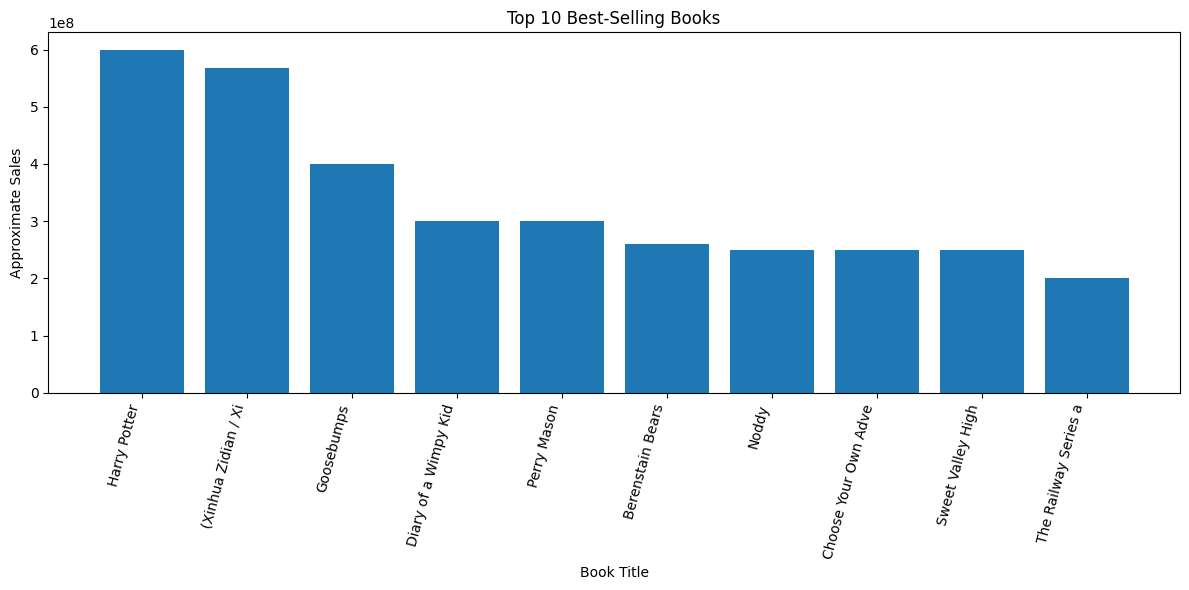

In [71]:
top_10_plot = Data.sort_values("Approximate Sales", ascending=False).head(10).copy()
top_10_plot["Book Title"] = top_10_plot["Book Title"].astype(str).str.encode("ascii", errors="ignore").str.decode("ascii").str[:20]

plt.figure(figsize=(12, 6))
plt.bar(top_10_plot["Book Title"], top_10_plot["Approximate Sales"])
plt.xticks(rotation=75, ha="right")
plt.title("Top 10 Best-Selling Books")
plt.xlabel("Book Title")
plt.ylabel("Approximate Sales")
plt.tight_layout()
plt.show()

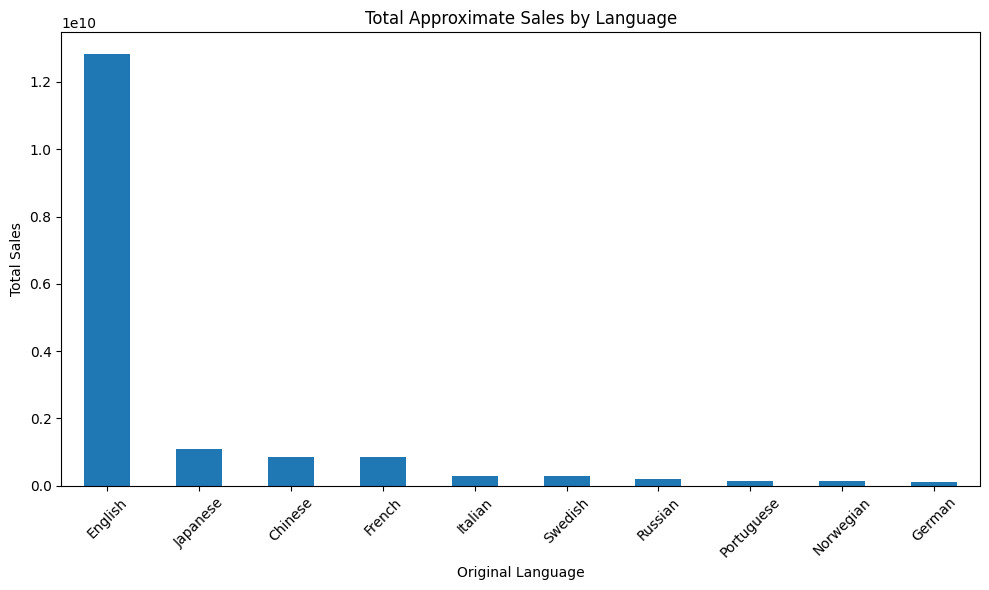

In [73]:
plt.figure(figsize=(10, 6))
sales_by_language.head(10).plot(kind="bar")
plt.title("Total Approximate Sales by Language")
plt.xlabel("Original Language")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

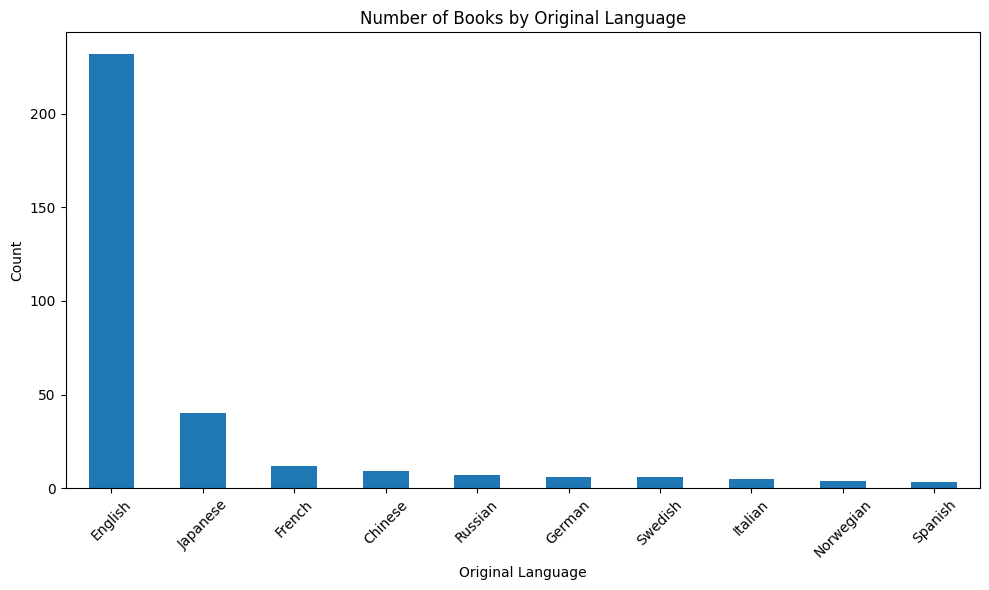

In [72]:
plt.figure(figsize=(10, 6))
books_by_language.head(10).plot(kind="bar")
plt.title("Number of Books by Original Language")
plt.xlabel("Original Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

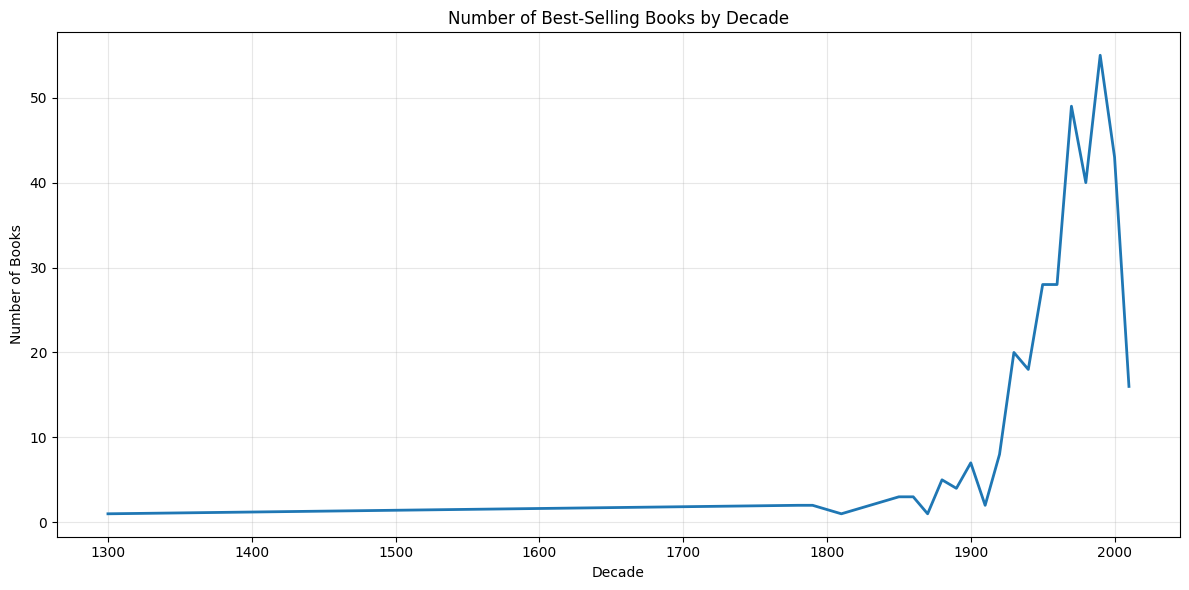

In [76]:
books_per_decade = (
    Data["First Published"]
    .dropna()
    .astype(int)
    .floordiv(10)
    .mul(10)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(books_per_decade.index, books_per_decade.values, linewidth=2)
plt.title("Number of Best-Selling Books by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Books")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()